# 🏋️ Diet & Fitness ML Project
## Shared Notebook — Data Understanding & Preparation


## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 60)

## 2. Load Dataset

In [2]:
df = pd.read_csv('dataset_Diet.csv', sep=';')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (21000, 54)


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Daily meals frequency,Physical exercise,Carbs,Proteins,Fats,Calories,meal_name,meal_type,diet_type,sugar_g,sodium_mg,cholesterol_mg,serving_size_g,cooking_method,prep_time_min,cook_time_min,rating,Name of Exercise,Sets,Reps,Benefit,Burns Calories (per 30 min),Target Muscle Group,Equipment Needed,Difficulty Level,Body Part,Type of Muscle,Workout,BMI_calc,cal_from_macros,pct_carbs,protein_per_kg,pct_HRR,pct_maxHR,cal_balance,lean_mass_kg,expected_burn,Burns Calories (per 30 min)_bc,Burns_Calories_Bin
0,22.83,Male,116.98,1.79,177.95,NaN,68.98,1.00,1079.1,Strength,35.000000,3.42,NaN,NaN,36.51,2.0,1.03,294.56,117.26,78.71,3054.0,Other,Breakfast,Balanced,0.52,1432.56,172.83,134.13,NaN,12.49,92.18,3.01,Step-ups,5.02,17.06,NaN,348.91,"Lower Chest, Triceps",Pull-up Bar,Beginner,Forearms,Wrist Flexors,Lateral raises,NaN,2355.67,NaN,1.002394,0.533817,0.714527,NaN,76.037000,697.820,8.431593e+19,High
1,25.44,Female,NaN,1.71,185.14,141.97,56.13,0.89,NaN,HIIT,18.934189,NaN,1.99,1.01,16.16,3.0,0.00,318.84,126.25,84.60,1204.0,Other,Breakfast,Paleo,41.08,2403.18,259.56,110.72,Grilled,10.69,103.03,3.27,Dead Bugs,5.01,17.99,Builds lower body power and endurance,NaN,"Legs, Core",Cable Machine or Resistance Band,Advanced,Chest,Posterior,Leg raises,16.162238,2541.76,0.501763,2.671392,0.665375,0.766825,126.12,38.311702,NaN,7.288169e+19,Medium
2,52.31,Male,70.57,1.69,164.81,134.90,65.03,1.35,1336.5,Strength,25.103023,2.20,2.97,1.00,24.71,NaN,-0.02,NaN,83.61,55.52,1868.0,NaN,Snack,NaN,39.89,1002.62,159.76,226.34,Steamed,60.23,78.24,4.00,Leg Press,NaN,15.96,Builds explosive power,336.67,"Triceps, Chest",Step or Box,Intermediate,NaN,Grip Strength,Barbell curls,24.708519,1670.48,0.500670,1.184781,0.700241,0.818518,531.50,52.854797,909.009,6.298462e+19,Low


## 3. Data Understanding
### 3.1 General Info

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21000 entries, 0 to 20999
Data columns (total 54 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             18867 non-null  float64
 1   Gender                          18923 non-null  object 
 2   Weight (kg)                     18880 non-null  float64
 3   Height (m)                      18899 non-null  float64
 4   Max_BPM                         18927 non-null  float64
 5   Avg_BPM                         18914 non-null  float64
 6   Resting_BPM                     18886 non-null  float64
 7   Session_Duration (hours)        18925 non-null  float64
 8   Calories_Burned                 18921 non-null  float64
 9   Workout_Type                    18895 non-null  object 
 10  Fat_Percentage                  18935 non-null  float64
 11  Water_Intake (liters)           18882 non-null  float64
 12  Workout_Frequency (days/week)   

In [4]:
df.describe()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Daily meals frequency,Physical exercise,Carbs,Proteins,Fats,Calories,sugar_g,sodium_mg,cholesterol_mg,serving_size_g,prep_time_min,cook_time_min,rating,Sets,Reps,Burns Calories (per 30 min),BMI_calc,cal_from_macros,pct_carbs,protein_per_kg,pct_HRR,pct_maxHR,cal_balance,lean_mass_kg,expected_burn,Burns Calories (per 30 min)_bc
count,18867.000000,18880.000000,18899.000000,18927.000000,18914.000000,18886.000000,18925.000000,18921.000000,18935.000000,18882.000000,18883.000000,18921.000000,18848.000000,18816.000000,18988.000000,18850.000000,18829.000000,18888.000000,18914.000000,18928.000000,18963.000000,18997.000000,18937.000000,18942.000000,18900.000000,18988.000000,18894.000000,18980.000000,18946.000000,18981.000000,18842.000000,18944.000000,18870.000000,18937.000000,18903.000000,18868.000000,18746.000000,18925.000000,1.888900e+04
mean,38.868996,73.899473,1.723901,179.907651,143.663359,62.190898,1.259570,1278.806094,26.082068,2.631606,3.317526,1.811187,24.917560,2.863001,0.453196,249.866000,99.893030,66.570357,2023.600032,24.543276,1257.478826,148.186024,302.632130,33.535619,61.579359,2.981457,4.425609,19.430003,344.260159,24.936622,1997.538979,0.499987,1.461383,0.698686,0.802040,744.136964,53.838648,865.377002,8.625291e+19
std,12.096714,21.190284,0.126949,11.510824,14.245347,7.278290,0.341904,500.236119,5.007846,0.603941,0.909892,0.736375,6.679286,0.638705,0.985299,55.138812,22.076741,14.659469,541.498681,14.443502,717.635085,87.393141,115.635351,16.534389,33.665637,1.157738,0.578988,3.676700,31.622006,6.697900,441.784477,0.001463,0.519568,0.144623,0.096679,719.186927,12.488795,249.807371,3.203041e+19
min,18.000000,39.180000,1.490000,159.310000,119.070000,49.490000,0.490000,323.110000,11.333134,1.460000,1.940000,1.000000,12.040000,1.950000,-0.070000,137.720000,55.170000,36.590000,781.000000,-0.670000,19.220000,-3.890000,95.950000,3.950000,3.350000,0.930000,2.960000,4.850000,128.750000,12.080861,1105.570000,0.493008,0.518142,0.371344,0.600302,-1266.220000,30.946261,219.852800,2.491905e+16
25%,28.220000,58.160000,1.620000,170.070000,131.220000,55.960000,1.050000,911.630000,22.348600,2.180000,2.980000,1.010000,20.100000,2.020000,-0.010000,207.570000,82.950000,55.340000,1634.000000,12.040000,641.095000,71.610000,206.990000,18.612500,32.360000,1.930000,4.000000,16.117500,337.642500,20.110607,1660.145000,0.499056,1.077386,0.584000,0.727376,261.087500,44.624856,713.340000,6.441978e+19
50%,39.870000,70.020000,1.710000,180.180000,142.935000,62.180000,1.270000,1231.200000,25.805969,2.610000,3.010000,1.990000,24.120000,3.000000,0.010000,242.700000,97.050000,64.735000,1917.000000,24.030000,1263.150000,149.400000,299.880000,34.330000,61.015000,2.990000,4.020000,19.890000,348.710000,24.114810,1940.655000,0.499984,1.382504,0.685550,0.794485,691.190000,51.329688,866.762000,8.366675e+19
75%,49.610000,86.000000,1.800000,189.380000,156.020000,68.080000,1.460000,1550.210000,29.660238,3.152500,4.000000,2.020000,28.590000,3.010000,0.040000,284.097500,113.640000,75.692500,2359.000000,37.550000,1852.295000,221.650000,401.940000,48.000000,89.642500,4.000000,5.000000,22.880000,360.520000,28.592684,2272.650000,0.500916,1.751148,0.797664,0.868797,1173.400000,61.983566,1011.517200,1.099881e+20
max,59.670000,130.550000,2.010000,199.640000,169.720000,74.500000,2.010000,2890.820000,35.000000,3.730000,5.060000,3.050000,50.230000,4.040000,4.050000,462.490000,185.340000,123.420000,3641.000000,50.510000,2526.340000,303.990000,507.520000,61.290000,121.460000,5.060000,5.040000,30.120000,381.710000,50.167818,3699.540000,0.507889,3.916881,1.073939,1.047032,3073.010000,90.117371,1477.108800,1.756614e+20


### 3.2 Target columns — value distributions

In [5]:
print('--- diet_type ---')
print(df['diet_type'].value_counts())
print()
print('--- meal_type ---')
print(df['meal_type'].value_counts())
print()
print('--- Workout_Type ---')
print(df['Workout_Type'].value_counts())

--- diet_type ---
diet_type
Paleo         3222
Low-Carb      3214
Vegan         3154
Vegetarian    3154
Keto          3135
Balanced      3067
Name: count, dtype: int64

--- meal_type ---
meal_type
Breakfast    4732
Lunch        4726
Dinner       4710
Snack        4692
Name: count, dtype: int64

--- Workout_Type ---
Workout_Type
Strength    4811
Yoga        4749
HIIT        4693
Cardio      4642
Name: count, dtype: int64


### 3.3 Missing values

In [6]:
missing_pct = df.isna().mean() * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)
print(f'{len(missing_pct)} columns have missing values:\n')
print(missing_pct)

54 columns have missing values:

lean_mass_kg                      10.733333
Daily meals frequency             10.400000
Difficulty Level                  10.361905
Proteins                          10.338095
cooking_method                    10.319048
cal_from_macros                   10.276190
Burns_Calories_Bin                10.252381
BMI                               10.247619
Carbs                             10.238095
Body Part                         10.233333
Equipment Needed                  10.233333
meal_type                         10.190476
Target Muscle Group               10.171429
Age                               10.157143
cal_balance                       10.152381
protein_per_kg                    10.142857
Weight (kg)                       10.095238
Name of Exercise                  10.090476
Water_Intake (liters)             10.085714
Workout_Frequency (days/week)     10.080952
meal_name                         10.076190
Benefit                           10.076190

### 3.4 Column types

In [7]:
num_cols = df.select_dtypes(include='number').columns
cat_cols = df.select_dtypes(include='object').columns
print(f'Numeric columns ({len(num_cols)}):', list(num_cols))
print()
print(f'Categorical columns ({len(cat_cols)}):', list(cat_cols))

Numeric columns (39): ['Age', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI', 'Daily meals frequency', 'Physical exercise', 'Carbs', 'Proteins', 'Fats', 'Calories', 'sugar_g', 'sodium_mg', 'cholesterol_mg', 'serving_size_g', 'prep_time_min', 'cook_time_min', 'rating', 'Sets', 'Reps', 'Burns Calories (per 30 min)', 'BMI_calc', 'cal_from_macros', 'pct_carbs', 'protein_per_kg', 'pct_HRR', 'pct_maxHR', 'cal_balance', 'lean_mass_kg', 'expected_burn', 'Burns Calories (per 30 min)_bc']

Categorical columns (15): ['Gender', 'Workout_Type', 'meal_name', 'meal_type', 'diet_type', 'cooking_method', 'Name of Exercise', 'Benefit', 'Target Muscle Group', 'Equipment Needed', 'Difficulty Level', 'Body Part', 'Type of Muscle', 'Workout', 'Burns_Calories_Bin']


### 3.5 Outlier visualisation (sample columns)

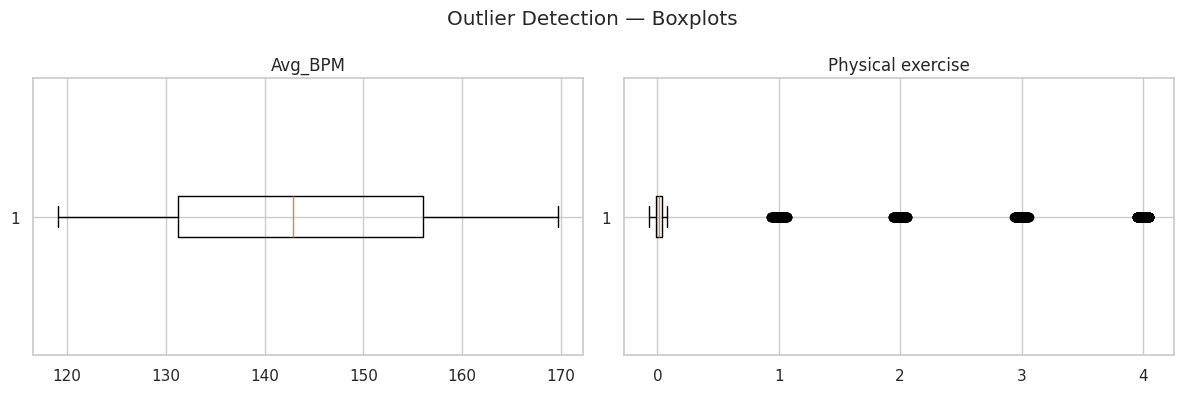

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(df['Avg_BPM'].dropna(), vert=False)
axes[0].set_title('Avg_BPM')
axes[1].boxplot(df['Physical exercise'].dropna(), vert=False)
axes[1].set_title('Physical exercise')
plt.suptitle('Outlier Detection — Boxplots')
plt.tight_layout()
plt.show()

## 4. Data Preparation
### 4.1 Impute missing values

In [9]:
# Numeric → median
num_imputer = SimpleImputer(strategy='median')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

# Categorical → most frequent
cat_imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

print('Missing values after imputation:', df.isna().sum().sum())

Missing values after imputation: 0


### 4.2 Remove duplicates

In [10]:
before = len(df)
df = df.drop_duplicates()
print(f'Removed {before - len(df)} duplicate rows. Rows remaining: {len(df)}')

Removed 1000 duplicate rows. Rows remaining: 20000


### 4.3 Remove outliers (IQR method)

In [11]:
num_cols = df.select_dtypes(include='number').columns  # refresh after drop_duplicates

Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

outlier_mask = ((df[num_cols] < (Q1 - 1.5 * IQR)) |
                (df[num_cols] > (Q3 + 1.5 * IQR))).any(axis=1)

print(f'Outlier rows detected: {outlier_mask.sum()}')
print(f'Rows before: {len(df)}')

df_clean = df[~outlier_mask].copy()
print(f'Rows after: {len(df_clean)}')

Outlier rows detected: 7784
Rows before: 20000
Rows after: 12216


### 4.4 Final check

In [12]:
print('Shape:', df_clean.shape)
print('Missing values:', df_clean.isna().sum().sum())
df_clean.info()

Shape: (12216, 54)
Missing values: 0
<class 'pandas.core.frame.DataFrame'>
Index: 12216 entries, 2 to 20999
Data columns (total 54 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             12216 non-null  float64
 1   Gender                          12216 non-null  object 
 2   Weight (kg)                     12216 non-null  float64
 3   Height (m)                      12216 non-null  float64
 4   Max_BPM                         12216 non-null  float64
 5   Avg_BPM                         12216 non-null  float64
 6   Resting_BPM                     12216 non-null  float64
 7   Session_Duration (hours)        12216 non-null  float64
 8   Calories_Burned                 12216 non-null  float64
 9   Workout_Type                    12216 non-null  object 
 10  Fat_Percentage                  12216 non-null  float64
 11  Water_Intake (liters)           12216 non-null  float64
 12  

## 5. Export clean dataset


In [13]:
df_clean.to_csv('df_clean.csv', index=False)
print('✅ df_clean.csv saved successfully.')

✅ df_clean.csv saved successfully.
